In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'  # Specify fonts that support Chinese
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['axes.unicode_minus'] = False  # Display the minus sign correctly

In [3]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
# master = "local[*]"
master = "local[10]"
# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "Introduction to Apache Spark"
# Setup configuration parameters for Spark
spark_conf = SparkConf().setMaster(master).setAppName(app_name)


In [4]:
# Import SparkContext and SparkSession classes
from pyspark import SparkContext # Spark
from pyspark.sql import SparkSession # Spark SQL

# Method 1: Using SparkSession
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel('ERROR')

# Method 2: Getting or instantiating a SparkContext
# sc = SparkContext.getOrCreate(spark_conf)
# sc.setLogLevel('ERROR')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/06/06 16:45:43 WARN Utils: Your hostname, Jiayis-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.4 instead (on interface en0)
25/06/06 16:45:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/06 16:45:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Loading data

In [5]:
attribute_file_path = '/Users/jiayiliu/Desktop/bigdata_project/obesity_level/obesity_level_attribute.csv'
result_file_path = '/Users/jiayiliu/Desktop/bigdata_project/obesity_level/obesity_level_result.csv'

# Reading CSV files using SparkSession
Attribute_df = spark.read.csv(attribute_file_path, header=True, inferSchema=True)
Result_df = spark.read.csv(result_file_path, header=True, inferSchema=True)


In [6]:
# View the first 5 rows
Attribute_df.show(5)

+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|    id|Gender|      Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|
+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+
|678333|  Male|     33.0|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile|
|648332|Female|     18.0|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|
|495333|Female|19.773303|1.602082|  45.0|                             0|   0| 3.0|3.0|Frequently|    0|2.875583|  1|1.269169|0.0|Sometimes|Public_Transporta...|
|155635|Female|     22.0|    1.71|

In [7]:
# View the first 5 rows
Result_df.show(5)

+------+-------------------+
|    id|            0be1dad|
+------+-------------------+
|678333| Overweight_Level_I|
|648332|Insufficient_Weight|
|495333|Insufficient_Weight|
|155635| Overweight_Level_I|
|909431|Insufficient_Weight|
+------+-------------------+
only showing top 5 rows


##### **Report**：
Through observation, it was found that the Obesity_level column name is incorrect and needs to be modified.

通过观察发现：Obesity_level列名不对，需修改

### 1.merge data

#### Merge two Attribute_df and Result_df to generate data based on id

In [8]:
data = Attribute_df.join(Result_df, on="id", how="inner")

In [9]:
data.show(5)

+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+
|    id|Gender|      Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|            0be1dad|
+------+------+---------+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+
|678333|  Male|     33.0|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|
|648332|Female|     18.0|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|Insufficient_Weight|
|495333|Female|19.773303|1.602082|  45.0|                             0|   0| 3.0|3.0|Frequentl

##### **Report**：
It is observed that the values ​​in the ‘Age’ column have decimal points. In order to facilitate observation and analysis, they need to be rounded off.

通过观察发现，‘Age’列中的值带小数点，为了方便观察分析，需将其四舍五入

#### View the structure of the DataFrame

In [10]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- Height: double (nullable = true)
 |-- Weight: double (nullable = true)
 |-- family_history_with_overweight: integer (nullable = true)
 |-- FAVC: integer (nullable = true)
 |-- FCVC: double (nullable = true)
 |-- NCP: double (nullable = true)
 |-- CAEC: string (nullable = true)
 |-- SMOKE: integer (nullable = true)
 |-- CH2O: double (nullable = true)
 |-- SCC: integer (nullable = true)
 |-- FAF: double (nullable = true)
 |-- TUE: double (nullable = true)
 |-- CALC: string (nullable = true)
 |-- MTRANS: string (nullable = true)
 |-- 0be1dad: string (nullable = true)



#### Descriptive Statistics

In [11]:
data.describe().show()

+-------+------------------+------+------------------+-------------------+------------------+------------------------------+------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+---------+----------+-------------------+
|summary|                id|Gender|               Age|             Height|            Weight|family_history_with_overweight|              FAVC|              FCVC|               NCP|     CAEC|               SMOKE|              CH2O|                SCC|               FAF|               TUE|     CALC|    MTRANS|            0be1dad|
+-------+------------------+------+------------------+-------------------+------------------+------------------------------+------------------+------------------+------------------+---------+--------------------+------------------+-------------------+------------------+------------------+---------+----------+-------------------+
|  coun

##### **Report**：
By observation, it is found that the "Obesity Level Column" has "0rmal_Weight", which should be changed to "Normal_Weight"

通过观察，发现 ‘肥胖水平列’出现了‘0rmal_Weight',应该将其更改为‘Normal_Weight’

#### Count the number of unique values ​​in each column

In [12]:
unique_values_count = {col: data.select(col).distinct().count() for col in data.columns}

unique_values_count

{'id': 20789,
 'Gender': 2,
 'Age': 1711,
 'Height': 1843,
 'Weight': 1991,
 'family_history_with_overweight': 2,
 'FAVC': 2,
 'FCVC': 934,
 'NCP': 689,
 'CAEC': 4,
 'SMOKE': 2,
 'CH2O': 1506,
 'SCC': 2,
 'FAF': 1360,
 'TUE': 1297,
 'CALC': 3,
 'MTRANS': 5,
 '0be1dad': 8}

##### **Report**：
There are too many fields such as ‘Age’/‘Height’/‘Weight’/‘FAF’, which may cause problems that are difficult to observe and understand during the visualization process, so data range division is required.

‘Age’/‘Height’/‘Weight’/‘FAF’等字段的数量过多，容易在可视化过程中出现不易观察不易理解的问题，所以需要进行数据范围划分。

#### View the unique values ​​of non-numeric columns

In [13]:
from pyspark.sql.types import IntegerType, LongType, FloatType, DoubleType, DecimalType, ByteType, ShortType 

In [14]:
# Identify non-numeric columns
non_numeric_cols = []
numeric_types = (IntegerType, LongType, FloatType, DoubleType, DecimalType, ByteType, ShortType)

for field in data.schema:
    if not isinstance(field.dataType, numeric_types):
        non_numeric_cols.append(field.name)

print(f"\n--- 识别到的非数值类型列: {non_numeric_cols} ---")
for col_name in non_numeric_cols:
    print(f"\n列名: '{col_name}'")

    # Get the data type of the column
    col_dtype = data.schema[col_name].dataType
    print(f"数据类型: {col_dtype}")
    # Get unique values
    unique_values_rows = data.select(col_name).distinct().collect()

    # Extract the actual value from the Row object
    unique_values = [row[col_name] for row in unique_values_rows]
    num_unique = len(unique_values)

    print(f"唯一值数量: {num_unique}")
    print(f"唯一值列表: {unique_values}")



--- 识别到的非数值类型列: ['Gender', 'CAEC', 'CALC', 'MTRANS', '0be1dad'] ---

列名: 'Gender'
数据类型: StringType()
唯一值数量: 2
唯一值列表: ['Female', 'Male']

列名: 'CAEC'
数据类型: StringType()
唯一值数量: 4
唯一值列表: ['Sometimes', '0', 'Frequently', 'Always']

列名: 'CALC'
数据类型: StringType()
唯一值数量: 3
唯一值列表: ['Sometimes', '0', 'Frequently']

列名: 'MTRANS'
数据类型: StringType()
唯一值数量: 5
唯一值列表: ['Bike', 'Walking', 'Automobile', 'Motorbike', 'Public_Transportation']

列名: '0be1dad'
数据类型: StringType()
唯一值数量: 8
唯一值列表: ['Obesity_Type_III', 'Overweight_Level_I', '0rmal_Weight', 'Obesity_Type_II', 'Insufficient_Weight', 'Overweight_Level_II', 'Normal_Weight', 'Obesity_Type_I']


##### **Report**：
The value 0 appears in the fields ‘CAEC’ and ‘CALC’, which does not match the other values. Based on the number of unique values ​​being 4 and 3 respectively, we can conclude that 0 means nothing, so we need to change it to Never.

‘CAEC’和‘CALC’这两个字段中出现数值0，与其他值不符合；又根据唯一值数量分别为4和3，可以判断0就是没有的意思，所以需要把它修改为Never 。

### 2. Clear Data

#### 2.1 Remove Unnecessary Columns and Fix Column Names

#### Rename the Obesity_level column in data

In [15]:
data = data.withColumnRenamed("0be1dad", "Obesity_level" )

In [16]:
from pyspark.sql.functions import when , col

#### Change the normal_Weight value in the Obesity_level column to Normal_Weight

In [17]:
data= data.withColumn("Obesity_level", 
                           when(col("Obesity_level") == "0rmal_Weight", "Normal_Weight")
                           .otherwise(col("Obesity_level")))

In [18]:
# Specify column names
columns_to_check = ['Obesity_level']

# View the different values ​​and specific contents of the specified column
for column in columns_to_check:
    print(f"字段名: {column}")
    
    # Get the different values ​​and their number
    value_counts = data.groupBy(column).count().orderBy(col("count").desc())
    print(f"不同值及其数量:")
    value_counts.show()

字段名: Obesity_level
不同值及其数量:
+-------------------+-----+
|      Obesity_level|count|
+-------------------+-----+
|   Obesity_Type_III| 4046|
|    Obesity_Type_II| 3248|
|      Normal_Weight| 3096|
|     Obesity_Type_I| 2913|
|Insufficient_Weight| 2530|
|Overweight_Level_II| 2529|
| Overweight_Level_I| 2427|
+-------------------+-----+



#### 2.2 Transfer Data Type

#### Age is rounded to the nearest integer (round)

In [19]:
from pyspark.sql.functions import round as round_func
from pyspark.sql.types import IntegerType

In [20]:
data = data.withColumn("Age", round_func(col("Age")).cast(IntegerType()))
data.select("Age").head(5)

[Row(Age=33), Row(Age=18), Row(Age=20), Row(Age=22), Row(Age=19)]

#### Change '0' in CAEC\CALC to 'Never'

In [21]:
data = data.withColumn("CAEC", when(col("CAEC") == "0", "Never").otherwise(col("CAEC")))
data = data.withColumn("CALC", when(col("CALC") == "0", "Never").otherwise(col("CALC")))

In [22]:
print("\nDifferent values ​​of CAEC and their quantities：")
caec_counts = data.groupBy("CAEC").count().orderBy(col("count").desc())
caec_counts.show()

print("\nDifferent values ​​of CALC and their quantities：")
calc_counts = data.groupBy("CALC").count().orderBy(col("count").desc())
calc_counts.show()


Different values ​​of CAEC and their quantities：
+----------+-----+
|      CAEC|count|
+----------+-----+
| Sometimes|17553|
|Frequently| 2479|
|    Always|  478|
|     Never|  279|
+----------+-----+


Different values ​​of CALC and their quantities：
+----------+-----+
|      CALC|count|
+----------+-----+
| Sometimes|15085|
|     Never| 5171|
|Frequently|  533|
+----------+-----+



#### 2.3 Duplicate

#### Check if there are duplicate values ​​in the ID column

In [23]:
# Count the number of occurrences of each id
id_counts = data.groupBy('id').count()

# Filter out ids that appear more than 1 times
duplicate_ids = id_counts.filter("count > 1").select('id')

# Check if there are duplicate ids in data
if duplicate_ids.count() > 0:
    print("ID 列有重复值。")
else:
    print("ID 列的值是唯一的。")

ID 列的值是唯一的。


#### Check all rows for duplicates

In [24]:
# Count the number of repetitions for each row
row_counts = data.groupBy(*data.columns).count()

# Filter out rows with a repetition count greater than 1
duplicate_rows = row_counts.filter(row_counts['count'] > 1)

# Count the number of duplicate rows
duplicate_rows_count = duplicate_rows.count()

print(f"The number of duplicate rows in the dataset is：{duplicate_rows_count}")


The number of duplicate rows in the dataset is：0


#### 2.4 Empty Lines

#### Check the number of missing values ​​in each column

In [25]:
for column in data.columns:
    null_count = data.filter(data[column].isNull()).count()
    print(f"The number of missing values ​​in column '{column}' is: {null_count}")

The number of missing values ​​in column 'id' is: 0
The number of missing values ​​in column 'Gender' is: 0
The number of missing values ​​in column 'Age' is: 0
The number of missing values ​​in column 'Height' is: 0
The number of missing values ​​in column 'Weight' is: 0
The number of missing values ​​in column 'family_history_with_overweight' is: 0
The number of missing values ​​in column 'FAVC' is: 0
The number of missing values ​​in column 'FCVC' is: 0
The number of missing values ​​in column 'NCP' is: 0
The number of missing values ​​in column 'CAEC' is: 0
The number of missing values ​​in column 'SMOKE' is: 0
The number of missing values ​​in column 'CH2O' is: 0
The number of missing values ​​in column 'SCC' is: 0
The number of missing values ​​in column 'FAF' is: 0
The number of missing values ​​in column 'TUE' is: 0
The number of missing values ​​in column 'CALC' is: 0
The number of missing values ​​in column 'MTRANS' is: 0
The number of missing values ​​in column 'Obesity_leve

#### Check the number of zero values ​​in each column

In [26]:
# Check if there is a zero value in each column
for column in data.columns:
    # Get the data type of the column
    column_type = data.schema[column].dataType.typeName()
    
    # Check if the column is a numeric type
    if column_type in ['integer', 'long', 'double', 'float', 'short', 'byte', 'decimal']:
        # Filter out rows where the value in each column is 0
        zero_count = data.filter(col(column) == 0).count()
        print(f"The number of zero values ​​in column '{column}' is: {zero_count}")
    else:
        print(f"Column '{column}' is not a numeric type, skipping zero value check.")

The number of zero values ​​in column 'id' is: 0
Column 'Gender' is not a numeric type, skipping zero value check.
The number of zero values ​​in column 'Age' is: 0
The number of zero values ​​in column 'Height' is: 0
The number of zero values ​​in column 'Weight' is: 2
The number of zero values ​​in column 'family_history_with_overweight' is: 3747
The number of zero values ​​in column 'FAVC' is: 1776
The number of zero values ​​in column 'FCVC' is: 0
The number of zero values ​​in column 'NCP' is: 0
Column 'CAEC' is not a numeric type, skipping zero value check.
The number of zero values ​​in column 'SMOKE' is: 20544
The number of zero values ​​in column 'CH2O' is: 0
The number of zero values ​​in column 'SCC' is: 20102
The number of zero values ​​in column 'FAF' is: 5059
The number of zero values ​​in column 'TUE' is: 6569
Column 'CALC' is not a numeric type, skipping zero value check.
Column 'MTRANS' is not a numeric type, skipping zero value check.
Column 'Obesity_level' is not a n

#### 2.5 Divide the scope

#### Divide the age range

In [27]:
data = data.withColumn("AgeRange", when(col("Age") <= 12, "Child")
                              .when((col("Age") >= 13) & (col("Age") <= 17), "Teenager")
                              .when((col("Age") >= 18) & (col("Age") <= 34), "Young Adult")
                              .when((col("Age") >= 35) & (col("Age") <= 44), "Middle Age")
                              .when((col("Age") >= 45) & (col("Age") <= 54), "Mature Adult")
                              .when((col("Age") >= 55) & (col("Age") <= 64), "Senior")
                              .otherwise("Elderly"))

In [28]:
data.show(5)

+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+
|    id|Gender|Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|      Obesity_level|   AgeRange|
+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+
|678333|  Male| 33|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|Young Adult|
|648332|Female| 18|    1.58|  39.0|                             0|   1| 2.8|3.0| Sometimes|    0|     2.0|  0|     2.0|1.0|Sometimes|Public_Transporta...|Insufficient_Weight|Young Adult|
|495333|Female| 20|1.602082|  45.0|                             0

#### Set limits for daily water consumption CH2O

In [29]:
data = data.withColumn(
    'CH2O_CategoryRange',
    when((col("CH2O") >= 0) & (col("CH2O") <= 1), '0-1L')   \
    .when((col("CH2O") > 1) & (col("CH2O") <= 2), '1-2L')   \
    .when((col("CH2O") > 2) & (col("CH2O") <= 3), '2-3L')    \
    .otherwise('>3L')
)

#### Define the range of motion frequency FAF

In [30]:
data = data.withColumn("FAFRange", when(col("FAF") <= 1, "low")
                              .when((col("FAF") > 1) & (col("FAF") <= 2), "medium")
                              .when((col("FAF") > 18) & (col("FAF") <= 3), "high")
                              .otherwise("other"))

#### NCP defines the number of times a main meal is consumed

In [31]:
data = data.withColumn(
    'NCP_CategoryRange',
    when((col("NCP") >= 0) & (col("NCP") <= 1), '0-2times')   \
    .when((col("NCP") > 1) & (col("NCP") <= 2), '1-2times')   \
    .when((col("NCP") > 2) & (col("NCP") <= 3), '2-3times')    \
    .otherwise('>3次')
)

In [32]:
data.show(5)

+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+------------------+--------+-----------------+
|    id|Gender|Age|  Height|Weight|family_history_with_overweight|FAVC|FCVC|NCP|      CAEC|SMOKE|    CH2O|SCC|     FAF|TUE|     CALC|              MTRANS|      Obesity_level|   AgeRange|CH2O_CategoryRange|FAFRange|NCP_CategoryRange|
+------+------+---+--------+------+------------------------------+----+----+---+----------+-----+--------+---+--------+---+---------+--------------------+-------------------+-----------+------------------+--------+-----------------+
|678333|  Male| 33|    1.67|  75.0|                             0|   1| 2.0|3.0| Sometimes|    0|     2.0|  0|     1.0|0.0|Sometimes|          Automobile| Overweight_Level_I|Young Adult|              1-2L|     low|         2-3times|
|648332|Female| 18|    1.58|  39.0|                             0|  

#### 2.6 Drop Outliers

#### Draw a box plot to view outliers

In [33]:
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType, ShortType, ByteType, DecimalType

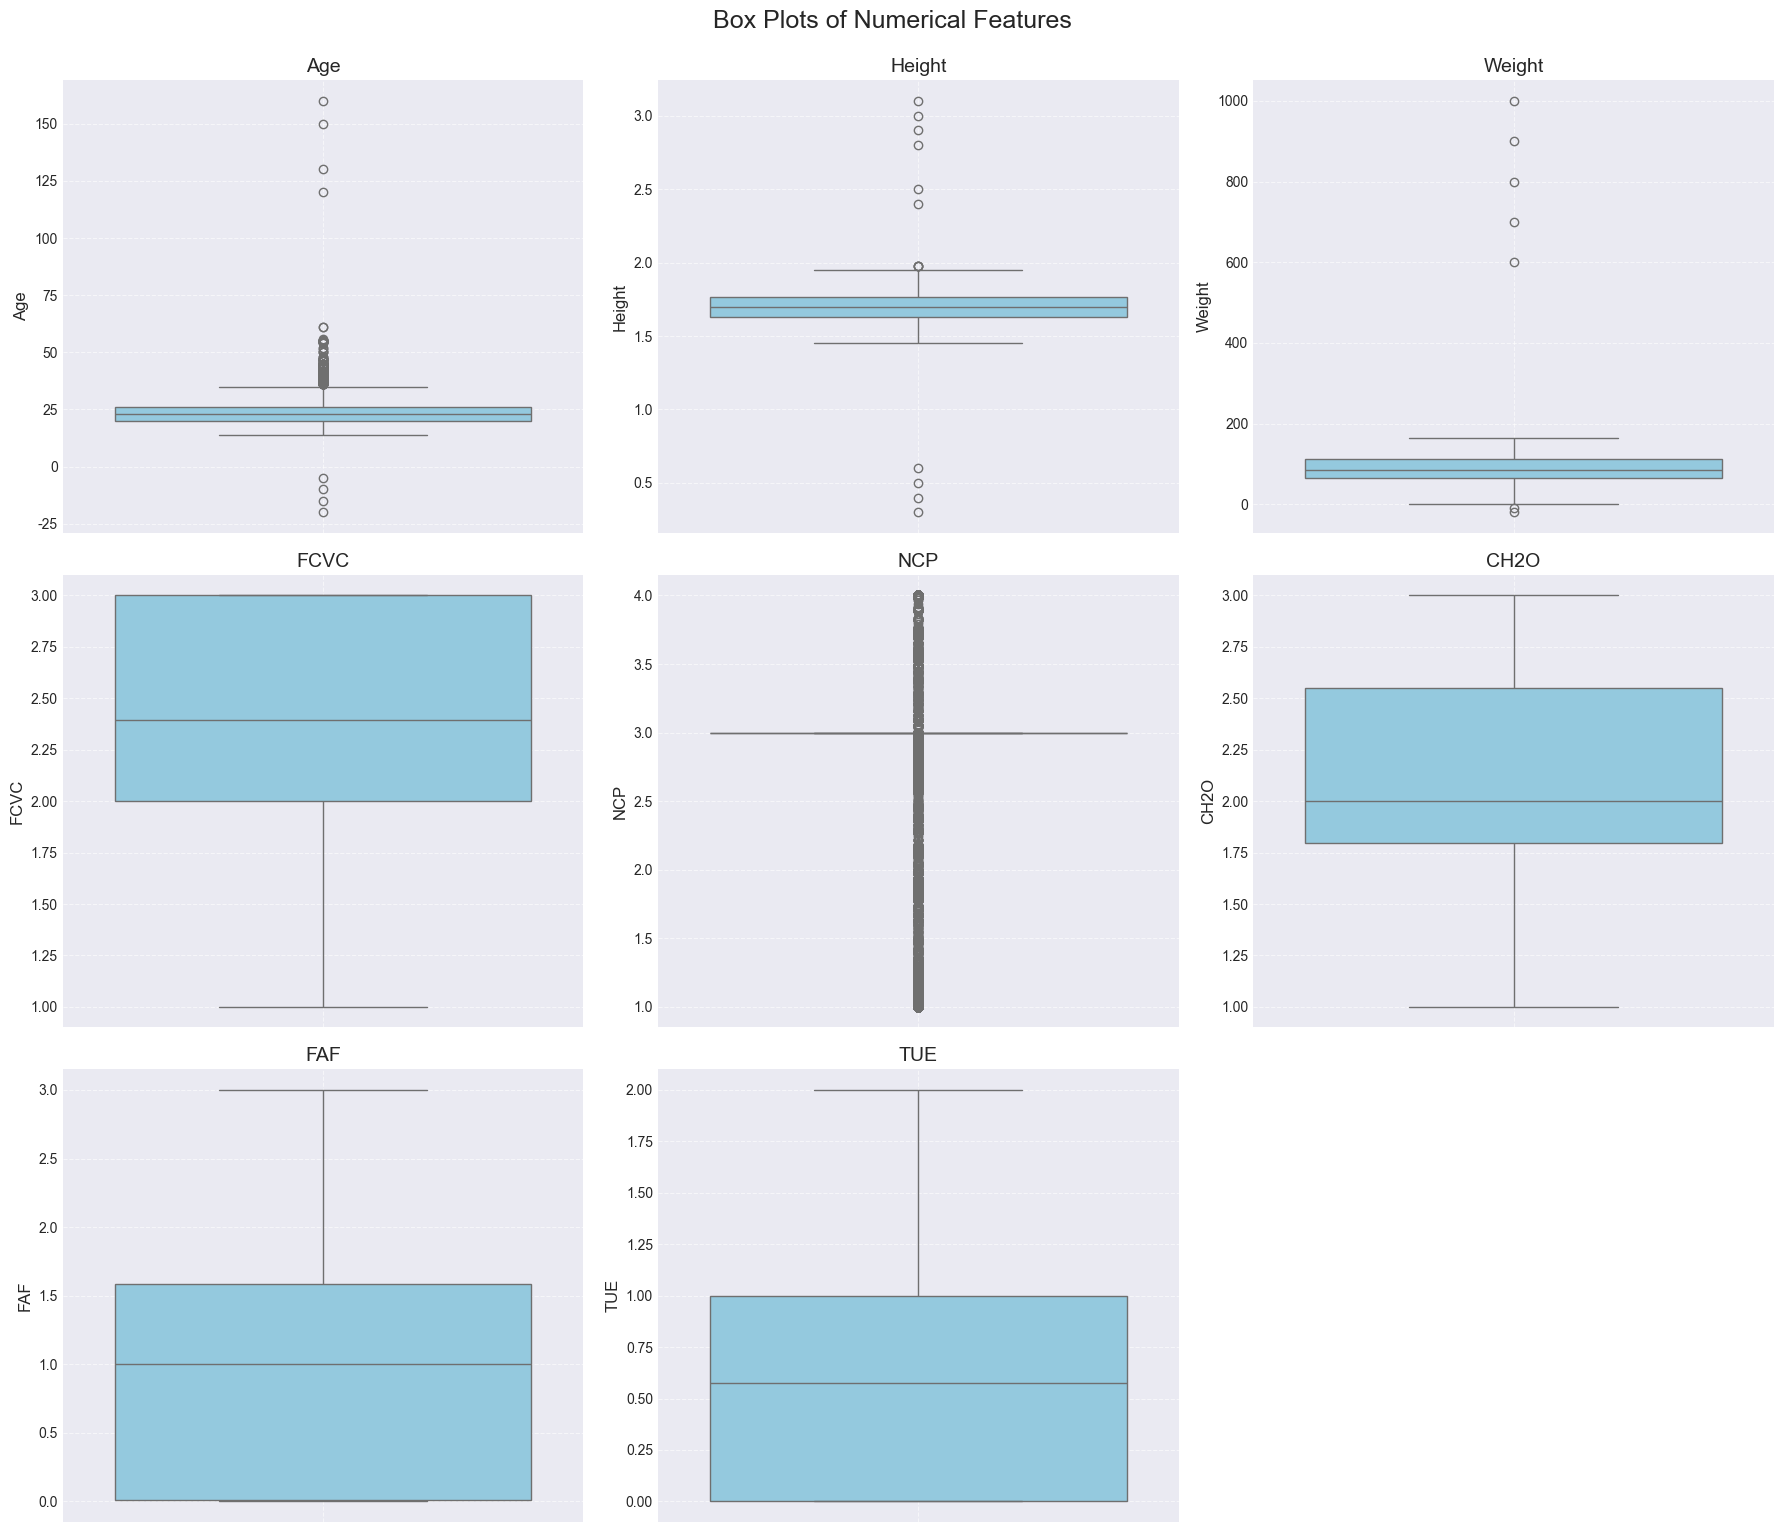

In [34]:
# Explicitly list all numeric fields
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

# Set Matplotlib style
plt.style.use('seaborn-v0_8-darkgrid') # Use seaborn style

# Create a figure and axes
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 2) // 3, ncols=3, figsize=(18, 5 * ((len(numeric_cols) + 2) // 3)))
axes = axes.flatten() # Convert axes to a 1D array for easy iteration

# Iterate over all numeric columns and draw box plots
for i, col in enumerate(numeric_cols):
    if i < len(axes): # Ensure index is within bounds
# Convert a single column of a PySpark DataFrame to Pandas Series
# Using toPandas() will pull data to Driver, be cautious when the amount of data is large
        pdf_series = data.select(col).toPandas()[col]

        sns.boxplot(y=pdf_series, ax=axes[i], color='skyblue') # Draw using seaborn
        axes[i].set_title(f'{col}', fontsize=14)
        axes[i].set_ylabel(col, fontsize=12)
        axes[i].tick_params(axis='y', labelsize=10) # Adjust the Y-axis tick label size
        axes[i].grid(True, linestyle='--', alpha=0.6) # Add grid lines

# Hide extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Automatically adjust the spacing between sub-graphs
plt.suptitle('Box Plots of Numerical Features', y=1.02, fontsize=18) # Add the overall title
plt.show()


##### **Report**:

- Some data in the Age column are outside the upper_bound, and some are very close to the upper_bound, which may be caused by the small amount of data in this part.Age列有部分数据在upper_bound之外，其中有部分距离upper_bound很近，有可能是因为这部分的数据量太少导致的。

- The NCP column represents the number of main meals used. Most of the values ​​are 3. 3 meals/day (breakfast, lunch, dinner) is the norm for most people. (Additional information: If more than 50% of the data in the data set is 3, then the median will be 3. If the data between 25% and 75% are also 3, then the box will become a line.)NCP列表示使用主餐的次数，绝大部分值都是3，3餐/天（早餐、午餐、晚餐）是大多数人的常态。（补充：如果数据集中 50% 以上的数据是 3，那么中位数就会是 3。如果 25% 到 75% 之间的数据也都是 3，那么箱体就会变成一条线。）

#### Specify a range to filter outliers in the Age column

In [35]:
from pyspark.sql.functions import col

In [36]:
filter_Age_before = data.count()
data = data.filter((col("Age") >= 0) & (col("Age") <= 100))
print(f"Filter the previous number of rows: {filter_Age_before}, Filtered rows: {data.count()}")

Filter the previous number of rows: 20789, Filtered rows: 20781


#### Specify Weight and Height to filter outliers

In [37]:
from pyspark.sql.functions import percentile_approx

In [38]:
# Define the columns that need IQR outlier filtering
columns_for_iqr_filter = ['Height', 'Weight']
                          
# Record the number of rows before filtering
filter_count_before = data.count()

# Loop through the columns and perform IQR outlier filtering
for col_name in columns_for_iqr_filter:
    
    # Calculate Q1 and Q3
    q1_q3 = data.agg(
        percentile_approx(col(col_name), 0.25).alias("q1"),
        percentile_approx(col(col_name), 0.75).alias("q3")
    ).collect()[0]

    q1 = q1_q3.q1
    q3 = q1_q3.q3

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Filter outliers
    data = data.filter(
        (col(col_name) >= lower_bound) & (col(col_name) <= upper_bound)
    )

# Record the number of rows after filtering and output
df = data.count()
print(f"Filter the previous number of rows: {filter_count_before}, Filtered rows: {df}")

Filter the previous number of rows: 20781, Filtered rows: 20772


### 2.6 describe date

####  Pie Chart

#### Gender Distribution

+------+-----+
|Gender|count|
+------+-----+
|Female|10430|
|  Male|10342|
+------+-----+



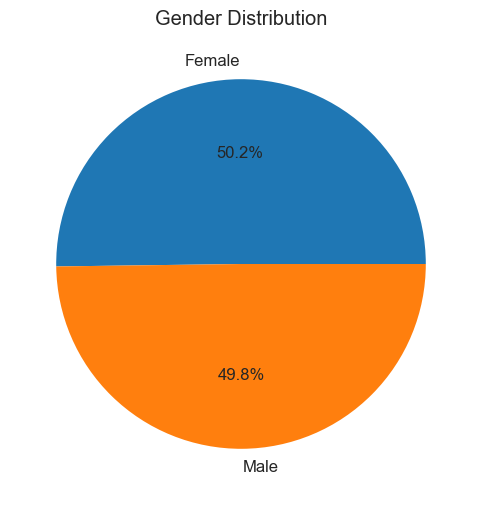

In [39]:
gender_counts = data.groupBy("Gender").count()
gender_counts.show()

# Convert to Pandas DataFrame to draw pie chart
gender_counts_pd = gender_counts.toPandas()
plt.figure(figsize=(8, 6))
plt.pie(gender_counts_pd['count'], labels=gender_counts_pd['Gender'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

##### **Report**：
From this pie chart, we can see that the ratio of men to women in this data set is basically even.通过此饼状图，可以得知该数据集的男女比例基本平均

#### Distribution of obesity levels

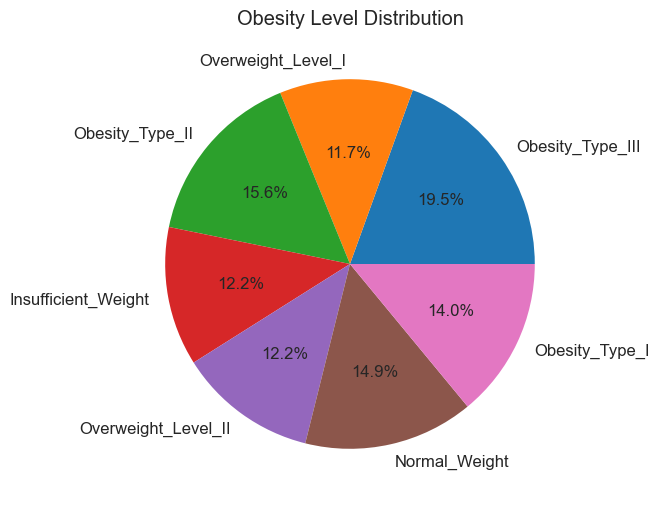

In [40]:
obesity_counts = data.groupBy("Obesity_level").count()

# Convert to Pandas DataFrame to draw pie chart
obesity_counts_pd = obesity_counts.toPandas()
plt.figure(figsize=(8, 6))
plt.pie(obesity_counts_pd['count'], labels=obesity_counts_pd['Obesity_level'], autopct='%1.1f%%')
plt.title('Obesity Level Distribution')
plt.show()

##### **Report**：
From this pie chart, we can see that the obesity level of men and women in this dataset is basically equal, among which ‘Obesity_Type_III’ has the largest proportion.通过此饼状图，可以得知该数据集的男女比例肥胖水平基本平均，其中 ‘Obesity_Type_III’比例最大。

#### The relationship between gender and obesity level

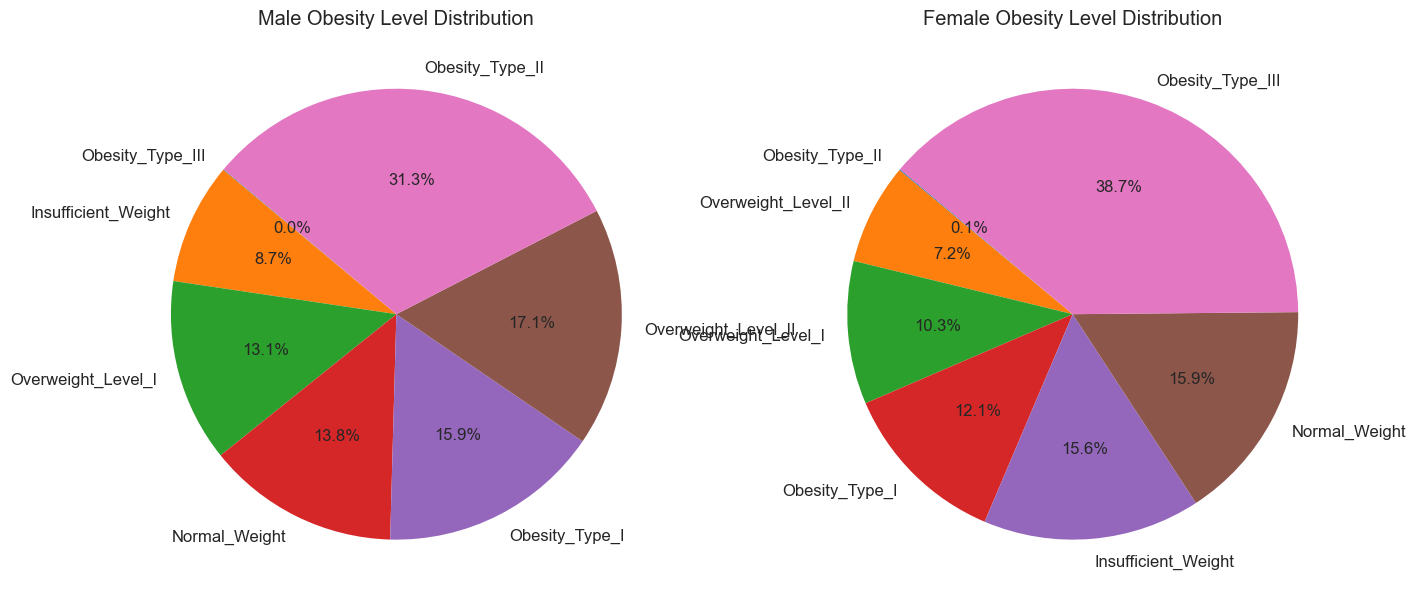

In [41]:
# Aggregate the Gender and Obesity_level fields
gender_obesity_counts = data.groupBy("Gender", "Obesity_level").count().orderBy("Gender", "count", descending=True)

# Convert the aggregation result to a Pandas DataFrame
gender_obesity_counts_pd = gender_obesity_counts.toPandas()

# Draw a pie chart
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#male
male_data = gender_obesity_counts_pd[gender_obesity_counts_pd['Gender'] == 'Male']
male_labels = male_data['Obesity_level']
male_sizes = male_data['count']
axes[0].pie(male_sizes, labels=male_labels, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Male Obesity Level Distribution')

#female
female_data = gender_obesity_counts_pd[gender_obesity_counts_pd['Gender'] == 'Female']
female_labels = female_data['Obesity_level']
female_sizes = female_data['count']
axes[1].pie(female_sizes, labels=female_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Female Obesity Level Distribution')

plt.show()

##### **Report**：
From this pie chart, we can see that in this data set, the proportion of ‘Obesity_Type_II’ is the largest among males and females, and the proportion of ‘Obesity_Type_II’ is the smallest.通过此饼状图，可以得知该数据集中，男性女性的‘Obesity_Type_II’占比最大，‘Obesity_Type_II’占比最少

#### The relationship between daily transportation mode and obesity level

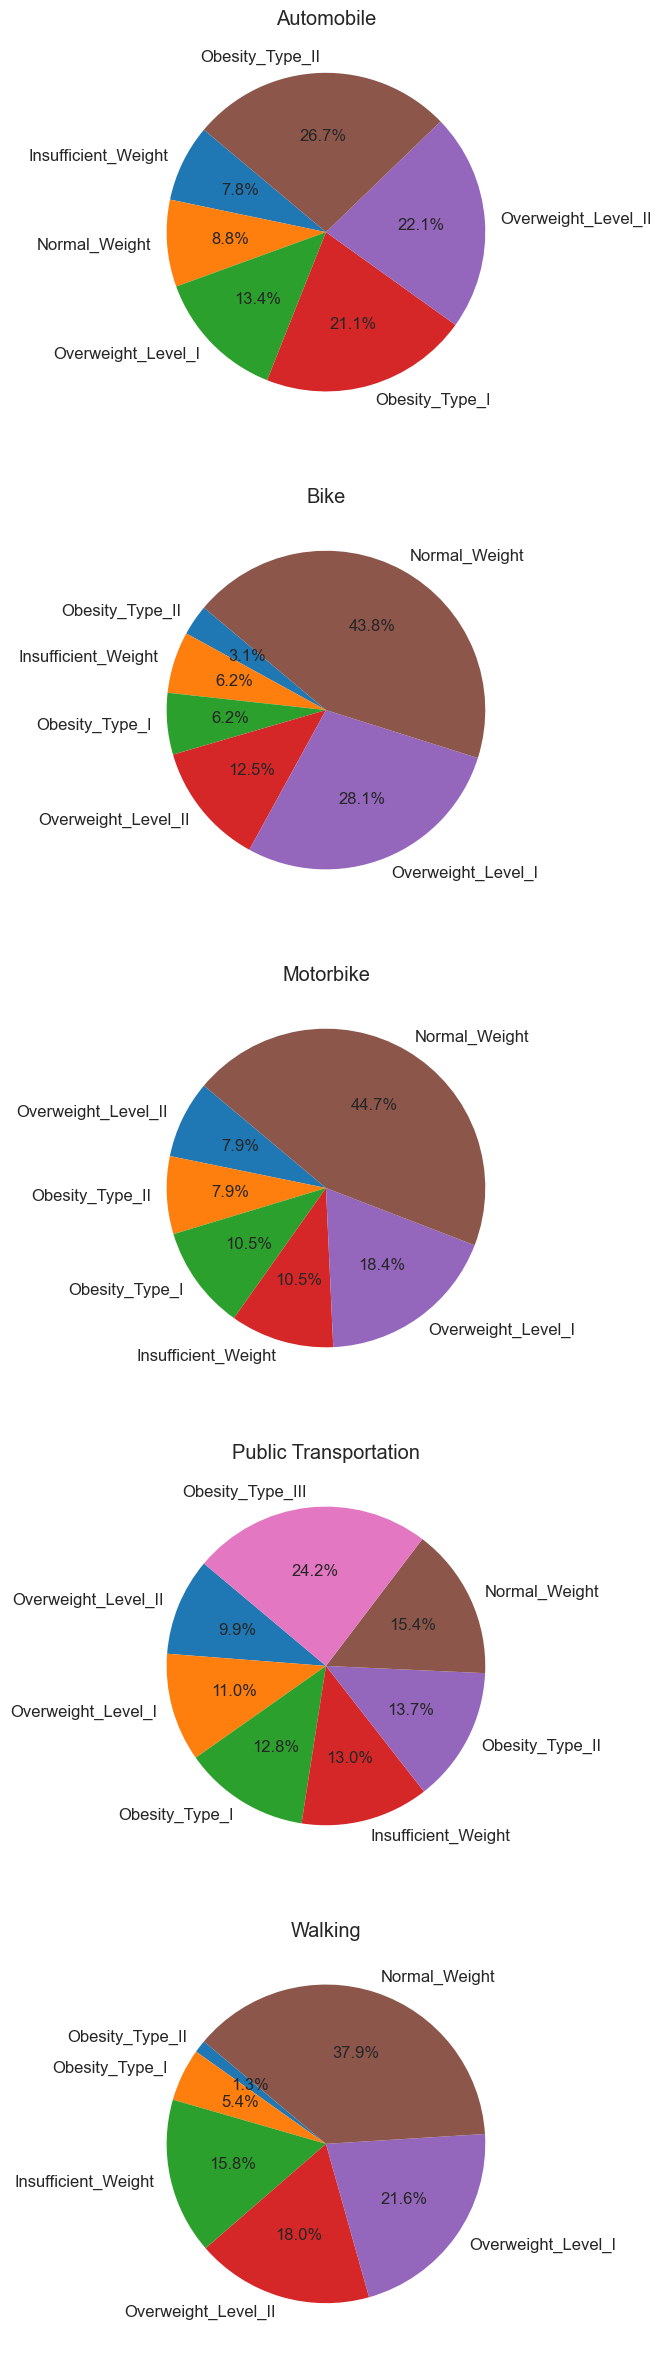

In [42]:
# Aggregate the MTRANS and Obesity_level fields
transport_obesity_counts = data.groupBy("MTRANS", "Obesity_level").count().orderBy("MTRANS", "count", descending=True)

# Convert the aggregation result to a Pandas DataFrame
transport_obesity_counts_pd = transport_obesity_counts.toPandas()

# Draw a pie chart
fig, axes = plt.subplots(5, 1, figsize=(80, 30))

# Automobile
auto_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Automobile']
auto_labels = auto_data['Obesity_level']
auto_sizes = auto_data['count']
axes[0].pie(auto_sizes, labels=auto_labels, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Automobile')

# Bike
bike_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Bike']
bike_labels = bike_data['Obesity_level']
bike_sizes = bike_data['count']
axes[1].pie(bike_sizes, labels=bike_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Bike')

# Motorbike
motorbike_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Motorbike']
motorbike_labels = motorbike_data['Obesity_level']
motorbike_sizes = motorbike_data['count']
axes[2].pie(motorbike_sizes, labels=motorbike_labels, autopct='%1.1f%%', startangle=140)
axes[2].set_title('Motorbike')

# Public Transportation
public_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Public_Transportation']
public_labels = public_data['Obesity_level']
public_sizes = public_data['count']
axes[3].pie(public_sizes, labels=public_labels, autopct='%1.1f%%', startangle=140)
axes[3].set_title('Public Transportation')

# Walking
walking_data = transport_obesity_counts_pd[transport_obesity_counts_pd['MTRANS'] == 'Walking']
walking_labels = walking_data['Obesity_level']
walking_sizes = walking_data['count']
axes[4].pie(walking_sizes, labels=walking_labels, autopct='%1.1f%%', startangle=140)
axes[4].set_title('Walking')

plt.show()

##### **Report**:
Obesity levels are lower in people who use bicycles and walk, while obesity levels are higher in people who use cars and public transport.使用自行车和步行的人群肥胖水平较低，而使用汽车和公共交通的人群肥胖水平较高。

#### Bar Chart

#### Relationship of age range to other fields

In [43]:
age_scc_counts = data.groupBy("AgeRange","SCC").count().toPandas()
age_mtrans_counts = data.groupBy("AgeRange","MTRANS").count().toPandas()
age_faf_counts = data.groupBy("AgeRange","FAFRange").count().toPandas()
age_obesity_counts = data.groupBy("AgeRange","Obesity_level").count().toPandas()

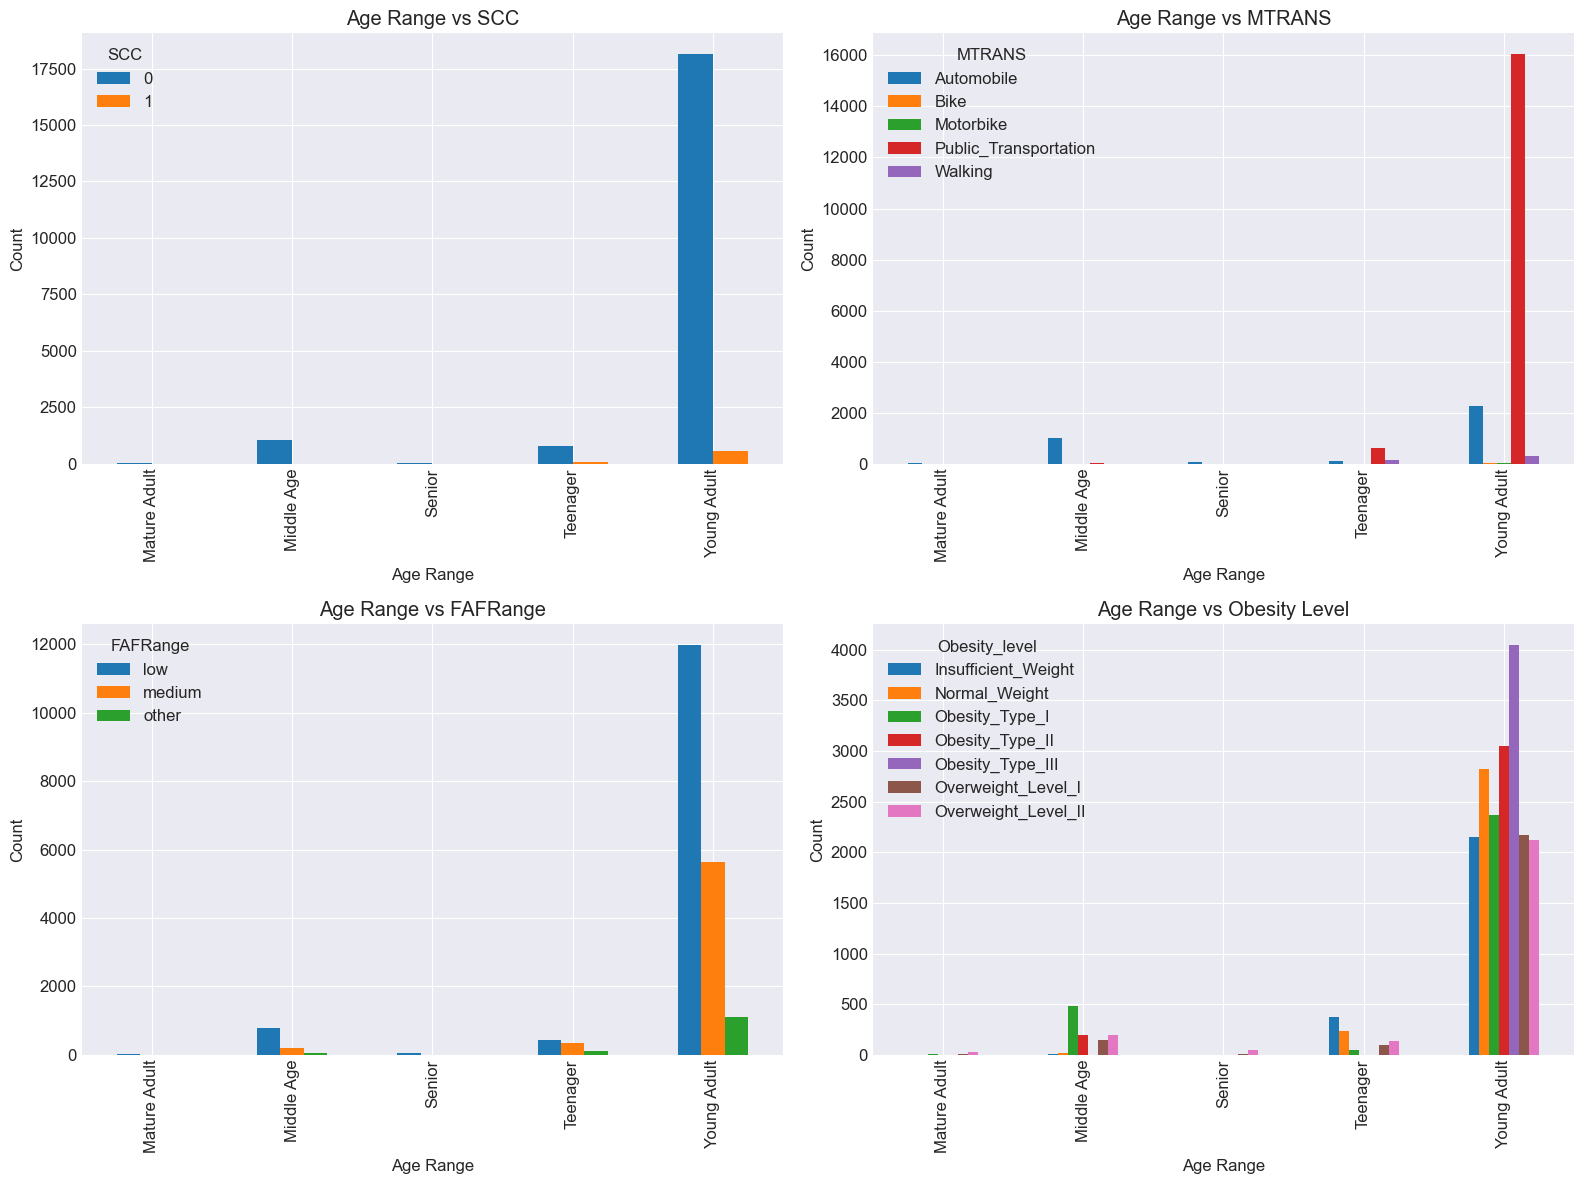

In [44]:
# Create a 2x2 graph
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Age range and relationship between high-calorie beverage consumption
age_scc_counts.pivot(index='AgeRange', columns='SCC', values='count').fillna(0).plot(kind='bar', ax=axs[0, 0])
axs[0, 0].set_title('Age Range vs SCC')
axs[0, 0].set_xlabel('Age Range')
axs[0, 0].set_ylabel('Count')

# Relationship between age range and daily transportation mode
age_mtrans_counts.pivot(index='AgeRange', columns='MTRANS', values='count').fillna(0).plot(kind='bar', ax=axs[0, 1])
axs[0, 1].set_title('Age Range vs MTRANS')
axs[0, 1].set_xlabel('Age Range')
axs[0, 1].set_ylabel('Count')

# Relationship between age range and exercise frequency
age_faf_counts.pivot(index='AgeRange', columns='FAFRange', values='count').fillna(0).plot(kind='bar', ax=axs[1, 0])
axs[1, 0].set_title('Age Range vs FAFRange')
axs[1, 0].set_xlabel('Age Range')
axs[1, 0].set_ylabel('Count')

# Age range and obesity level
age_obesity_counts.pivot(index='AgeRange', columns='Obesity_level', values='count').fillna(0).plot(kind='bar', ax=axs[1, 1])
axs[1, 1].set_title('Age Range vs Obesity Level')
axs[1, 1].set_xlabel('Age Range')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


##### Report:
- Age Range vs SCC
    - Leave blank: because it is not clear what 0 and 1 represent
- Age Range vs MTRANS
    - People aged 18-34 (Young Adult) mainly choose public transportation (Public_Transportation), with a number of nearly 16,000 people, while other modes of transportation such as automobiles and bicycles are relatively few.

- Age Range vs FAF
    - People aged 18-34 (Young Adult) consume more high-calorie beverages, followed by people aged 13-17 (Teenager) and 35-44 (Middle Age).

- Age Range vs Obesity Level
    - People aged 18-34 (Young Adult) have a serious obesity problem.

>存疑：1. 0/1问题；

#### Line Chart


#### The relationship between daily water consumption and obesity levels

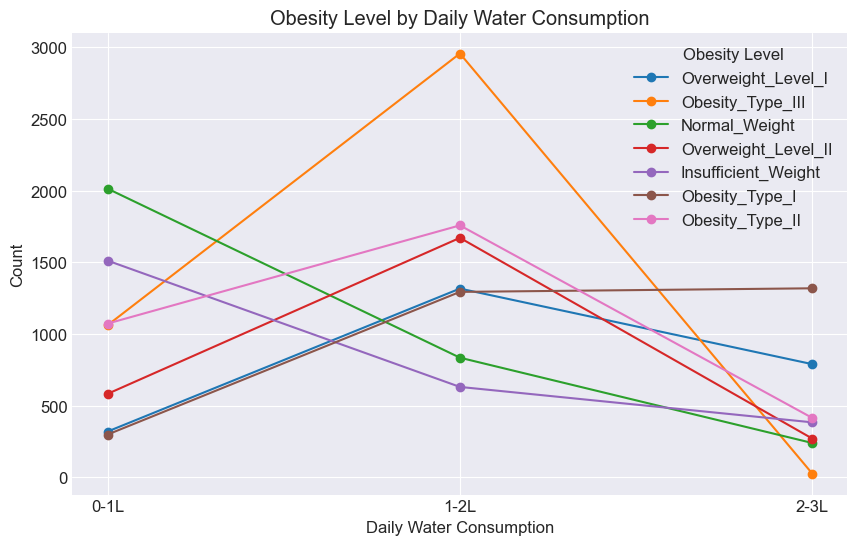

In [45]:
# Statistics on the distribution of different obesity levels in each interval
obesity_counts = data.groupBy("CH2O_CategoryRange", "Obesity_level").count()

# Convert the result to a Pandas DataFrame
obesity_counts_pd = obesity_counts.toPandas()

# Draw a line chart
fig, ax = plt.subplots(figsize=(10, 6))

# Get the labels for the intervals and obesity levels
categories = obesity_counts_pd['CH2O_CategoryRange'].unique()
obesity_levels = obesity_counts_pd['Obesity_level'].unique()

# Draw a line graph for each obesity level
for level in obesity_levels:
    level_data = obesity_counts_pd[obesity_counts_pd['Obesity_level'] == level]
    ax.plot(categories, level_data['count'], marker='o', label=level)

ax.set_title('Obesity Level by Daily Water Consumption')
ax.set_xlabel('Daily Water Consumption')
ax.set_ylabel('Count')
ax.legend(title='Obesity Level')
plt.show()

#### Scatter Chart

##### The relationship between height and weight based on gender

In [46]:
# Convert to Pandas DataFrame
df_pd = data.toPandas()

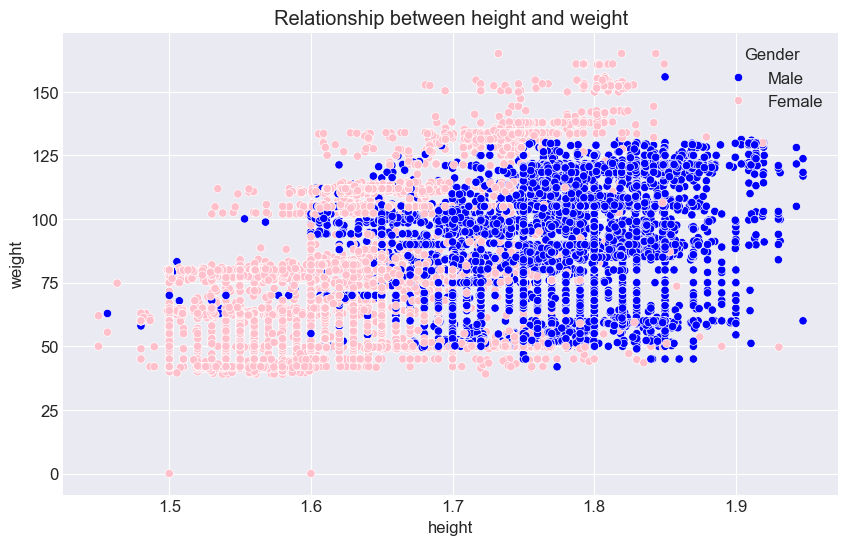

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Weight', hue='Gender', data=df_pd , palette={'Male': 'blue', 'Female': 'pink'})
plt.title('Relationship between height and weight')
plt.xlabel('height')
plt.ylabel('weight')
plt.legend(title='Gender')
plt.show()

##### **Report**：
Through observation, it was found that height and weight have an insignificant positive correlation.通过观察，发现身高与体重有不明显的正相关。

#### The relationship between exercise frequency and daily water consumption

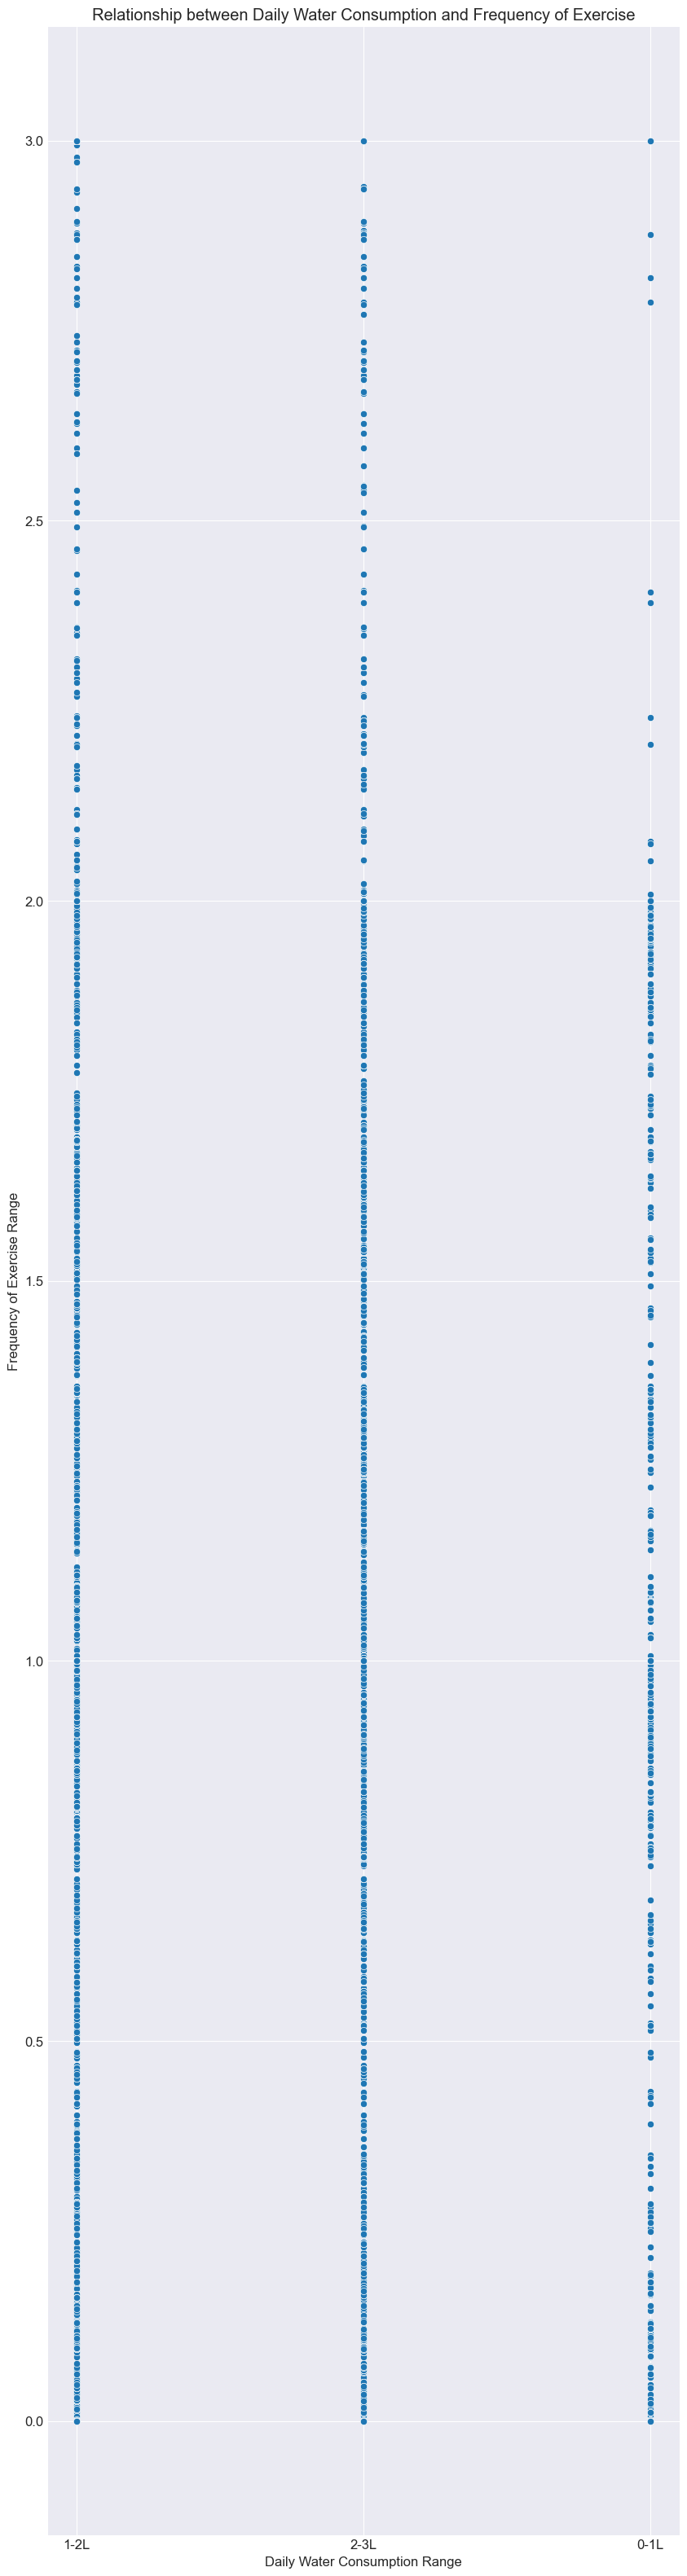

In [48]:
plt.figure(figsize=(10, 40))
sns.scatterplot(x='CH2O_CategoryRange', y='FAF', data=df_pd )
plt.title('Relationship between Daily Water Consumption and Frequency of Exercise')
plt.xlabel('Daily Water Consumption Range')
plt.ylabel('Frequency of Exercise Range')
plt.show()

##### **Report**:

There is no obvious connection between the two.两者没有太明显的关联。

#### violin

/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_1986/3520976806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_1986/3520976806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
/var/folders/23/snrgtk4j63j0s4txk_mdvjjr0000gn/T/ipykernel_1986/3520976806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Obesity_leve

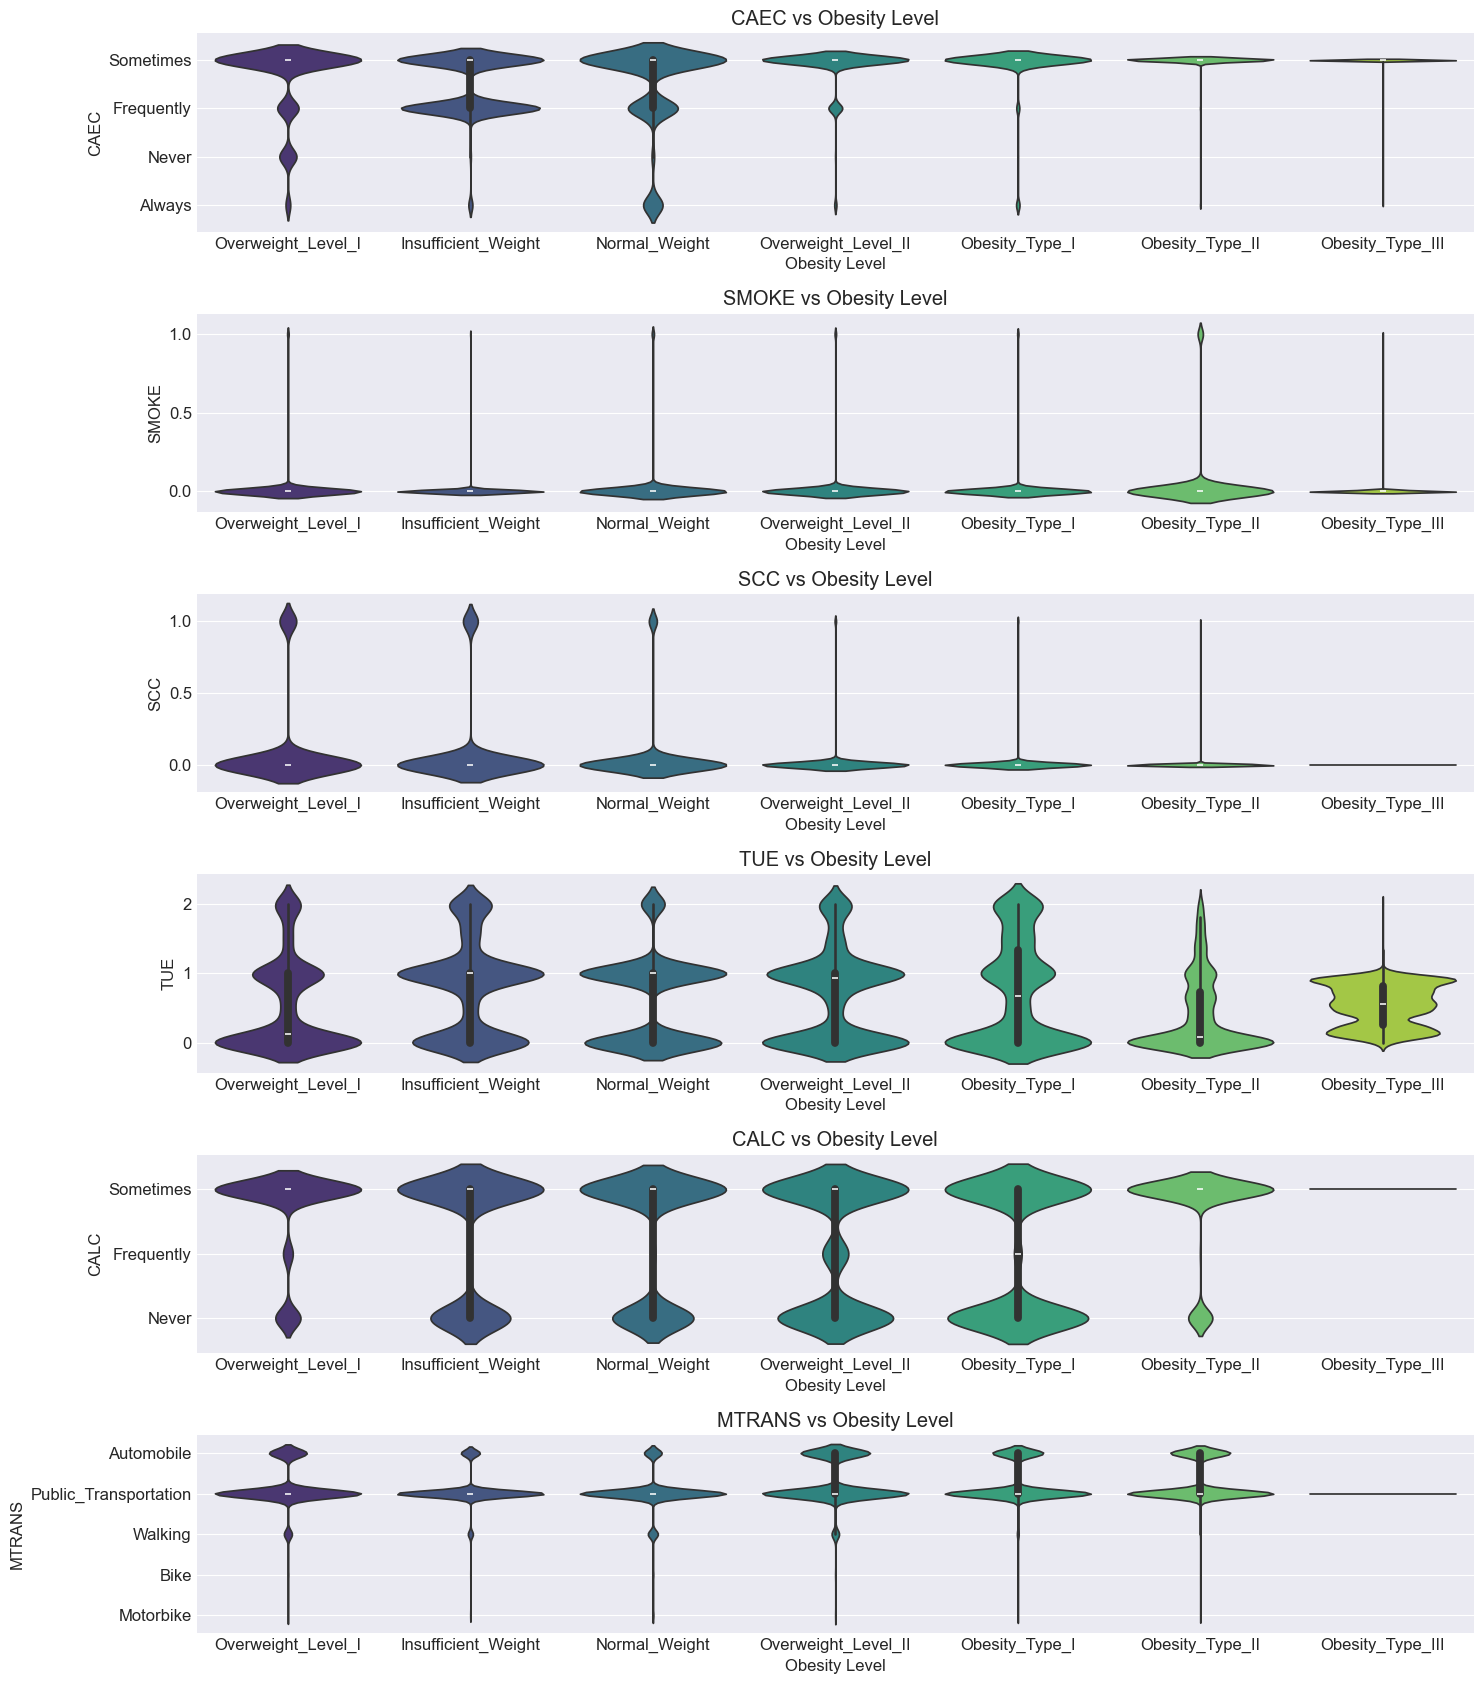

In [49]:
# Create a figure and subplots
continuous_vars = ['CAEC', 'SMOKE', 'SCC', 'TUE', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(15, 17))
axes = axes.flatten()

# Draw violin plots for each variable
for i, var in enumerate(continuous_vars):
    sns.violinplot(x='Obesity_level', y=var, data= df_pd , ax=axes[i], palette='viridis')
    axes[i].set_title(f'{var} vs Obesity Level')
    axes[i].set_xlabel('Obesity Level')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

##### Report:
- Food consumption between meals (CAEC): Individuals with higher obesity levels tend to consume more frequently.餐之间的食品消费（CAEC）：肥胖水平较高的个体更倾向于频繁消费。

- Whether smoking (SMOKE): The relationship between smoking and obesity levels is not obvious.吸烟与肥胖水平之间的关系不明显。

- High-calorie beverage consumption (SCC): The consumption of high-calorie beverages is more common in individuals with higher obesity levels.高热量饮料的消耗量在肥胖水平较高的个体中更为常见。

- Time using electronic devices (TUE): The relationship between the time using electronic devices and obesity levels is more complicated, but individuals with higher obesity levels tend to spend more time on electronic devices.使用电子设备的时间与肥胖水平之间的关系较为复杂，但肥胖水平较高的个体倾向于花费更多时间在电子设备上。

- Alcohol consumption (CALC): No obvious correlation was shown.未显示出明显的相关性。

- Daily transportation mode (MTRANS): There is a certain association between daily transportation mode and obesity levels. Individuals with higher obesity levels are more likely to choose to use cars, while individuals with lower obesity levels are more likely to walk or ride a bicycle.日常交通方式与肥胖水平之间存在一定的关联。肥胖水平较高的个体更可能选择使用汽车，而肥胖水平较低的个体更倾向于步行或骑自行车。

#### Heatmap

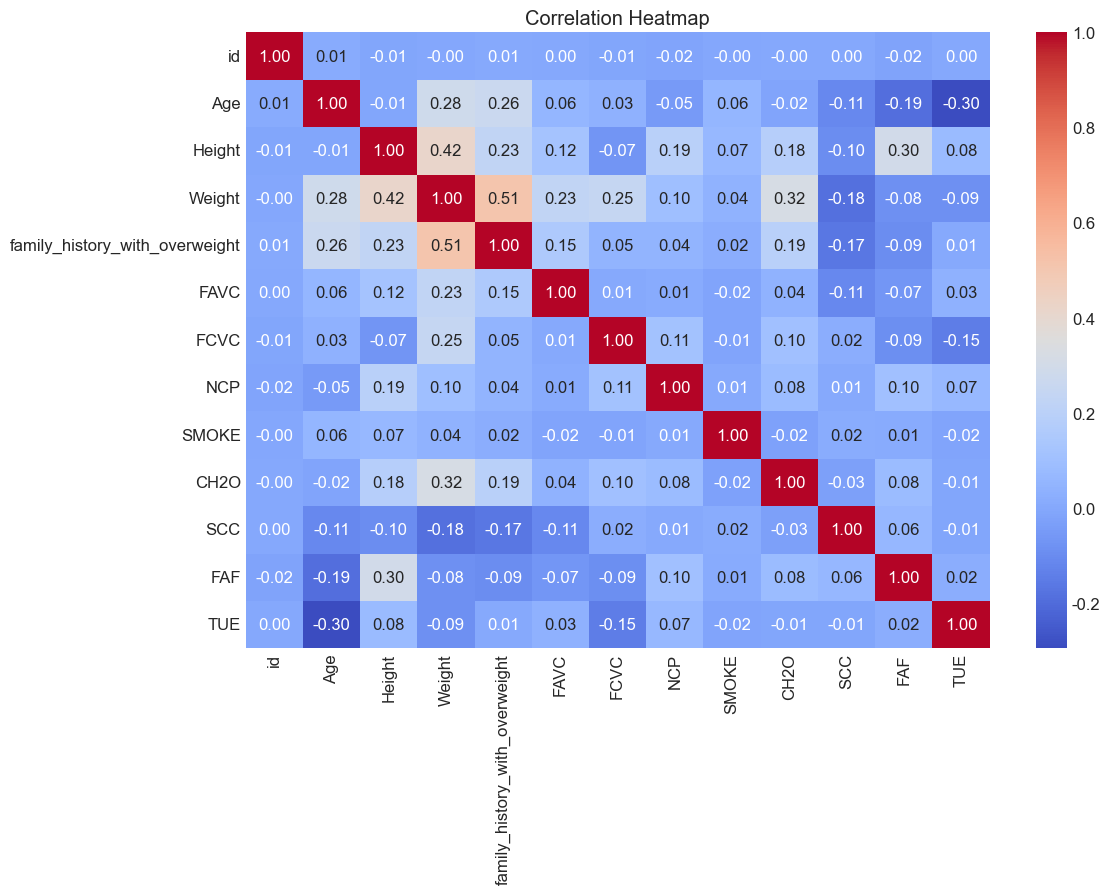

In [50]:
# Select numeric columns
numeric_columns = [col for col, dtype in data.dtypes if dtype in ['int', 'double', 'float']]

# Initialize the correlation matrix
corr_matrix = pd.DataFrame(np.zeros((len(numeric_columns), len(numeric_columns))),
                           index=numeric_columns, columns=numeric_columns)

# Calculate the correlation between each pair of columns
for col1 in numeric_columns:
    for col2 in numeric_columns:
        corr_value = data.stat.corr(col1, col2)
        corr_matrix.loc[col1, col2] = corr_value

# Draw a heat map
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

##### **Report**:

Red indicates positive correlation, blue indicates negative correlation, and the darker the color, the stronger the correlation.红色表示正相关，蓝色表示负相关，颜色越深，相关性越强。

- Weight and Height: There is a moderate positive correlation between weight and height (correlation coefficient is 0.42), which indicates that as height increases, weight tends to increase.体重（Weight）与身高（Height）：体重与身高之间存在中等程度的正相关（相关系数为 0.42），这表明随着身高的增加，体重也倾向于增加。

- Weight and family history of overweight: There is a strong positive correlation between weight and family history of overweight (correlation coefficient is 0.51), which may indicate that family history of obesity has a significant impact on individual weight.体重（Weight）与家族肥胖史（family_history_with_overweight）：体重与家族肥胖史之间存在较强的正相关（相关系数为 0.51），这可能表明家族肥胖史对个体体重有显著影响。

- Weight and frequent consumption of high-calorie foods (FAVC): There is a moderate positive correlation between weight and frequent consumption of high-calorie foods (correlation coefficient is 0.51), which indicates that frequent consumption of high-calorie foods may increase weight.体重（Weight）与是否频繁食用高热量食物（FAVC）：体重与是否频繁食用高热量食物之间存在中等程度的正相关（相关系数为 0.51），这表明频繁食用高热量食物可能增加体重。

- Age and time spent using electronic devices (TUE): There is a strong negative correlation between age and time spent using electronic devices (correlation coefficient is -0.30), which may indicate that people spend less time using electronic devices as they age.年龄（Age）与使用电子设备的时间（TUE）：年龄与使用电子设备的时间之间存在较强的负相关（相关系数为 -0.30），这可能表明随着年龄的增长，人们使用电子设备的时间减少。

- Exercise frequency (FAF) and age (Age): There was a moderate negative correlation between exercise frequency and age (correlation coefficient of -0.19), which may indicate that people exercise less frequently as they age.运动频率（FAF）与年龄（Age）：运动频率与年龄之间存在中等程度的负相关（相关系数为 -0.19），这可能表明随着年龄的增长，人们的运动频率降低。

- Daily water consumption (CH2O) and high-calorie beverage consumption (SCC): There was a moderate negative correlation between daily water consumption and high-calorie beverage consumption (correlation coefficient of -0.03), which may indicate that the consumption of high-calorie beverages may reduce total daily water consumption.每日耗水量（CH2O）与高热量饮料消耗量（SCC）：每日耗水量与高热量饮料消耗量之间存在中等程度的负相关（相关系数为 -0.03），这可能表明高热量饮料的消耗可能会减少每日的总耗水量。

#### Density

#### Relationship between FCVC (frequency of vegetable consumption) and NCP (number of main meals consumed)

In [51]:
# Get unique values
ncp_categories = data.select("NCP_CategoryRange").distinct().rdd.flatMap(lambda x: x).collect()

Pandas has an interface for drawing graphs and is integrated with matplotlib and seaborn (cooperation)

pyspark itself does not draw graphs

In [52]:
# Convert to Pandas DataFrame
df_pd = data.toPandas()

/opt/miniconda3/envs/big_data/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


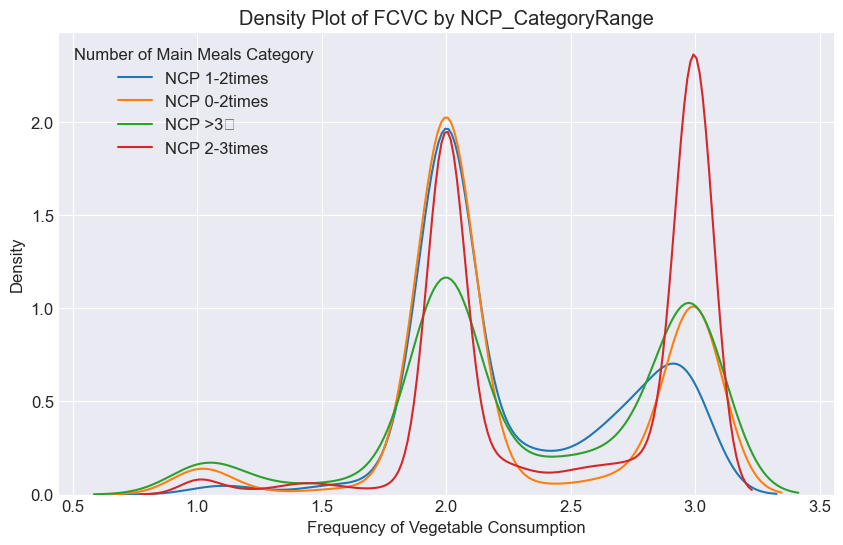

In [53]:
plt.figure(figsize=(10, 6))
for ncp_category in ncp_categories:
    subset = df_pd [df_pd ['NCP_CategoryRange'] == ncp_category]
    sns.kdeplot(subset['FCVC'], label=f'NCP {ncp_category}')
plt.title('Density Plot of FCVC by NCP_CategoryRange')
plt.xlabel('Frequency of Vegetable Consumption')
plt.ylabel('Density')
plt.legend(title='Number of Main Meals Category')
plt.show()

##### **Report**：
- The main meal consumers with NCP of 0-2 times showed a bimodal distribution in FCVC, indicating that this group has two different habits in vegetable consumption.NCP 为 0-2次的主餐消费者在 FCVC 上呈现出双峰分布，表明这一群体在蔬菜消费上存在两种不同的习惯。

- The main meal consumers with NCP of 1-2 times and 2-3 times had a more concentrated distribution in FCVC, and the peak appeared at a higher FCVC value, showing a more consistent vegetable consumption habit.NCP 为 1-2次和 2-3次的主餐消费者在 FCVC 上的分布较为集中，且峰值出现在较高的 FCVC 值，显示出较为一致的蔬菜消费习惯。

- The main meal consumers with NCP of more than 3 times had a more dispersed distribution in FCVC, but also showed a certain concentration trend.NCP 超过3次的主餐消费者在 FCVC 上的分布较为分散，但同样显示出一定的集中趋势。